In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

Dataset Loaded Successfully!

Feature Matrix Shape : (178, 13)
Target Shape : (178,)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Training Samples : 142
Testing Samples : 36

Decision Tree Accuracy : 94.44 %
Random Forest Accuracy : 100.0 %

MODEL COMPARISON
Decision Tree : 94.44 %
Random Forest : 100.0 %

Random Forest performed better!

Feature Importance:

                         Feature  Importance
6                     flavanoids    0.202293
9                color_intensity    0.171202
12                       proline    0.139046
0                        alcohol    0.112398
11  od280/od315_of_diluted_wines    0.111564
10                           hue    0.070891
4                      magnesium    0.036841
1                     malic_acid    0.035703
3              alcalinity_of_ash    0.032425
5     

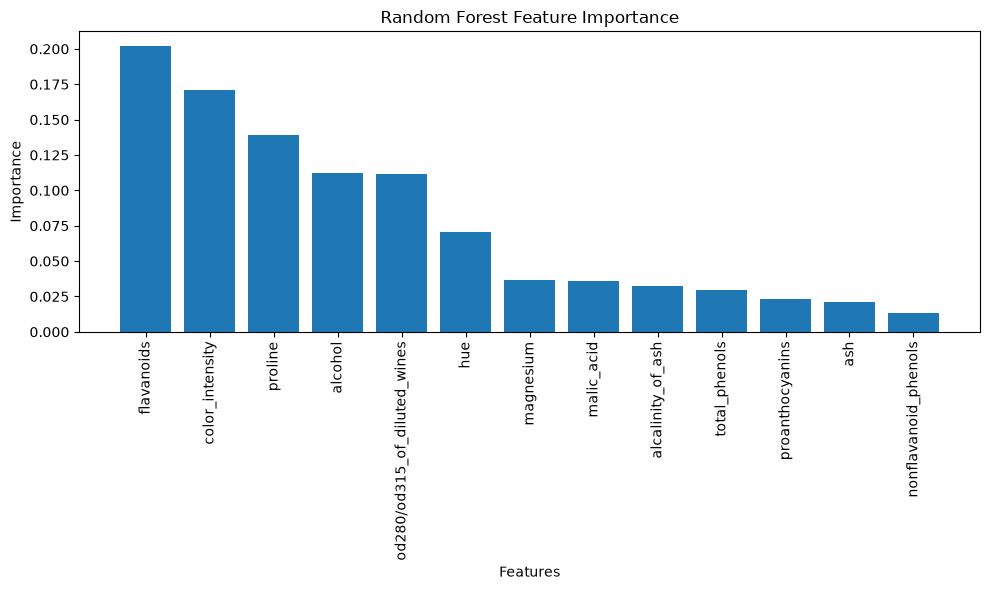


Changing n_estimators
n_estimators = 10  Accuracy = 0.9444
n_estimators = 25  Accuracy = 1.0000
n_estimators = 50  Accuracy = 1.0000
n_estimators = 100 Accuracy = 1.0000
n_estimators = 200 Accuracy = 1.0000

Changing max_features
max_features = sqrt  Accuracy = 1.0000
max_features = log2  Accuracy = 1.0000
max_features = None  Accuracy = 0.9722

Program Completed Successfully!


In [2]:
# ==========================================
# Random Forest vs Decision Tree
# ==========================================

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# 2. Load Dataset
# ==========================================

wine = load_wine()

X = wine.data
y = wine.target

print("Dataset Loaded Successfully!\n")

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nFeature Names:")
print(wine.feature_names)

# ==========================================
# 3. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

# ==========================================
# 4. Decision Tree
# ==========================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("\nDecision Tree Accuracy :", round(dt_acc * 100,2), "%")

# ==========================================
# 5. Random Forest
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_acc * 100,2), "%")

# ==========================================
# 6. Comparison
# ==========================================

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
print("Decision Tree :", round(dt_acc * 100,2), "%")
print("Random Forest :", round(rf_acc * 100,2), "%")

if rf_acc > dt_acc:
    print("\nRandom Forest performed better!")
elif rf_acc < dt_acc:
    print("\nDecision Tree performed better!")
else:
    print("\nBoth models performed equally!")

# ==========================================
# 7. Feature Importance
# ==========================================

importance = rf.feature_importances_

feature_names = wine.feature_names

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:\n")
print(importance_df)

# Plot Feature Importance
plt.figure(figsize=(10,6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=90)

plt.title("Random Forest Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

# ==========================================
# 8. Hyperparameter Tuning
# ==========================================

print("\n===================================")
print("Changing n_estimators")
print("===================================")

estimators = [10,25,50,100,200]

for n in estimators:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    print(f"n_estimators = {n:<3} Accuracy = {acc:.4f}")

# ==========================================
# 9. max_features Tuning
# ==========================================

print("\n===================================")
print("Changing max_features")
print("===================================")

features = ["sqrt","log2",None]

for f in features:

    model = RandomForestClassifier(
        n_estimators=100,
        max_features=f,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    print(f"max_features = {str(f):<5} Accuracy = {acc:.4f}")

print("\n===================================")
print("Program Completed Successfully!")
print("===================================")